### Haldane Sphere Geometry
- **ν**: Filling factor 1/3 (or 1/5, 2/5, etc.) (Laughlin state)
- **N_phi**: Number of orbitals
- **2S**: Number of Magnetic monopoles
- **N_phi = ?**: Number of electrons
- **Shifted angular momentum orbitals**

### Interaction Details
- **Coulomb Interaction**: V(q) = W₀ × 1/|ql|
- **Units**: Energy in units of W₀ = e²/ϵl

### Key Physics
- **Angular Momentum conservation**: Total angular momentum L_z is conserved
- **Ground state degeneracy**: non degenerate ground state on sphere for Laughlin states

In [1]:
# These packages are not included in the MomentumED package. 
# Use the following line to add them:

# using Pkg; Pkg.add("CairoMakie"); Pkg.add("FastGaussQuadrature"); Pkg.add("WignerSymbols")

In [1]:
# Import the momentum-conserved exact diagonalization package
using MomentumED, LinearAlgebra
include("../Landau level sphere.jl")
using .LLS        # due to the world age, we can only run this once

using CairoMakie # for plotting
CairoMakie.activate!()

# optional MKLSparse can accelecrate the sparse MatVec multiplication, other sparse packages helps as well
# using MKL, MKLSparse
# MKL.BLAS.set_num_threads(1)


SYSTEM: caught exception of type :MethodError while trying to print a failed Task notice; giving up


In [22]:
# Plot the energy spectrum
function plot_ed_spectrum(energies, ss_k;
    title = nothing, ylims = (nothing, nothing),
    ylabel = "Energy per unit cell (W₀ = e²/ϵl)",
    top_subspace_number = true, size = (600, 450))

    fig = Figure(; size);
    ax = Axis(fig[1, 1];
        xlabel = "Total angular momentum Lz",
        ylabel = ylabel
    )
    ax_top = Axis(fig[1, 1];
        xaxisposition = :top
    )
    top_ticks = ([], [])
    hidespines!(ax_top)
    hidexdecorations!(ax_top; label = false, ticklabels = false)
    hideydecorations!(ax_top)
    linkxaxes!(ax, ax_top)

    # Plot energy levels for each momentum block
    Lz_shift = (ss_k[begin][1] + ss_k[end][1]) ÷ 2
    for i in eachindex(ss_k)
        x = ss_k[i][1] - Lz_shift
        push!(top_ticks[1], x)
        push!(top_ticks[2], string(i))
        if isassigned(energies,i)
            scatter!(ax, repeat([x], length(energies[i])), energies[i], color = :blue, marker=:hline)
        end
    end
    ylims!(ax, ylims...)
    top_subspace_number && (ax_top.xticks = top_ticks)
    if title isa String
        ax_top.subtitle = title
    end
    display(fig)
    fig, ax
end
# Plot the orbital reduced entanglement spectrum
function plot_entanglement_spectrum(entanglement_spectrum;
    title=nothing, ylims = (nothing, nothing))

    fig = Figure();
    ax = Axis(fig[1,1];
        xlabel = "Ne in A-part",
        xticksvisible = false,
        xgridvisible = false,
        xminorgridvisible = true,
    )

    x = 0
    NA_lines = Float64[-0.5;]
    xtickposition = Float64[];
    xticklabel = String[];
    for indexNA in CartesianIndices(entanglement_spectrum)
        x_begin = x
        for (indexkA, spectrum) in enumerate(entanglement_spectrum[indexNA])
            if !isempty(spectrum)
                for e in spectrum
                    scatter!(ax, x, e, color = :blue, marker=:hline)
                end
                x += 1
            end
        end
        x_end = x
        if x_end > x_begin
            NA = string(indexNA[1]-1)
            for i in 2:length(indexNA)
                NA *= ",$(indexNA[i]-1)"
            end
            push!(xtickposition, 0.5(x_begin+x_end-1))
            push!(xticklabel, NA)
            push!(NA_lines, x-0.5)
        end
    end
    ax.xticks = (xtickposition, xticklabel)
    ax.xminorticks = NA_lines
    if title isa String
        ax.subtitle = title
    end
    ylims!(ax, ylims...)
    display(fig)
    fig
end

plot_entanglement_spectrum (generic function with 1 method)

Define the system and compute the eigen eneneies and wavefunctions, constructing the Hamiltonian as a sparse matrix.

In [3]:
# System parameters
N_orb = 19      # Total number of orbitals
Ne = 7          # Ne electrons; for 1/3 filling Laughlin state, Ne=(N_orb+2)÷3

7

In [4]:
# Set up component parameters: (layer, level index, Chern number, pseudospin)
sys_int = SphereLandauInteraction(N_orb, (1, 0, 1, 0)); # only one n=0 Landau level with Chern number 1

# Coulomb
# compute the pseudo-potential components
generate_Coulomb_interaction(sys_int)
@show sys_int.V_intra_Coulomb

# Haldane pseudo-potential
sys_int.V_intra = [0.0; 1.0; 0.0; 0.0]          # Intralayer Haldane pseudo-potential in unit of W0

# choose a linear mixing between Haldane and Coulomb interaction
sys_int.mix = 1                 # mix * Haldane + (1-mix) * Coulomb

# Create parameter structure for monolayer system
k_list = Matrix(collect(0:(N_orb-1))')  # k-mesh for the sphere geometry, shifted angular momentum Lz = 0, 1, ..., N_orb-1
Gk = Tuple(0)                           # angular momentum with only one component for the sphere geometry and no reciprocal lattice vector
para = EDPara(; k_list, Gk, H_two = sys_int);

sys_int.V_intra_Coulomb = [0.931800631642888, 0.472282511928587, 0.3592007837203338, 0.30367216015004067, 0.269679007894439, 0.2464451241373797, 0.22949387221258635, 0.21659491920766344, 0.20649939331239095, 0.19844873470372076, 0.1919540488406899, 0.18668601319497632, 0.1824154181218886, 0.17897902092022028, 0.1762589750095787, 0.174169979750206, 0.17265105550819837, 0.17166023166023164, 0.17117117117117117]


In [5]:
# Create momentum blocks (Hilbert subspace)
subspaces, ss_k = ED_momentum_subspaces(para, Ne);
println.(collect(zip(length.(subspaces), ss_k)))
ss_center = (length(subspaces)+1)÷2
println("subspace center index is $ss_center")

# one-body terms are all zero in flat Landau level
scat = ED_scatterlist_twobody(para);

(1, (21,))
(1, (22,))
(2, (23,))
(3, (24,))
(5, (25,))
(7, (26,))
(11, (27,))
(15, (28,))
(21, (29,))
(28, (30,))
(38, (31,))
(49, (32,))
(65, (33,))
(81, (34,))
(103, (35,))
(127, (36,))
(157, (37,))
(189, (38,))
(229, (39,))
(270, (40,))
(320, (41,))
(372, (42,))
(432, (43,))
(493, (44,))
(564, (45,))
(633, (46,))
(711, (47,))
(788, (48,))
(871, (49,))
(950, (50,))
(1036, (51,))
(1114, (52,))
(1197, (53,))
(1271, (54,))
(1346, (55,))
(1410, (56,))
(1475, (57,))
(1524, (58,))
(1572, (59,))
(1605, (60,))
(1634, (61,))
(1646, (62,))
(1656, (63,))
(1646, (64,))
(1634, (65,))
(1605, (66,))
(1572, (67,))
(1524, (68,))
(1475, (69,))
(1410, (70,))
(1346, (71,))
(1271, (72,))
(1197, (73,))
(1114, (74,))
(1036, (75,))
(950, (76,))
(871, (77,))
(788, (78,))
(711, (79,))
(633, (80,))
(564, (81,))
(493, (82,))
(432, (83,))
(372, (84,))
(320, (85,))
(270, (86,))
(229, (87,))
(189, (88,))
(157, (89,))
(127, (90,))
(103, (91,))
(81, (92,))
(65, (93,))
(49, (94,))
(38, (95,))
(28, (96,))
(21, (97,))


In [15]:
Neigen = 2000  # Number of eigenvalues to compute per subspace
ss_range = eachindex(subspaces) # pick some subspaces to compute, e.g., ss_range = 1:5
# ss_range = ss_center-5:ss_center+5
energies = [Vector{Float64}() for _ in ss_range];
vectors = Vector{Vector{<:MBS64Vector}}(undef, length(ss_range));
for i in eachindex(ss_range)
    println("Processing subspace #$i with size $(length(subspaces[ss_range[i]])), momentum $(ss_k[ss_range[i]])")
    energies[i], vectors[i] = EDsolve(subspaces[ss_range[i]], scat;
        N = Neigen, showtime = true, ishermitian = true, method_info = false,
        # method = :dense          # use dense matrix for Hamiltonian, works better when size is smaller than 100.
        method = :dense, max_dense_dim = Neigen        # use dense matrix for Hamiltonian, works better when size is smaller than 100.
        # method = :sparse          # default method
    )
end

Processing subspace #1 with size 1, momentum (21,)
  0.000315 seconds (111 allocations: 26.429 KiB)
  0.000016 seconds (22 allocations: 1.312 KiB)
Processing subspace #2 with size 1, momentum (22,)
  0.000182 seconds (98 allocations: 26.038 KiB)
  0.000006 seconds (22 allocations: 1.312 KiB)
Processing subspace #3 with size 2, momentum (23,)
  0.000226 seconds (108 allocations: 28.272 KiB)
  0.000015 seconds (24 allocations: 2.609 KiB)
Processing subspace #4 with size 3, momentum (24,)
  0.000168 seconds (115 allocations: 30.085 KiB)
  0.000021 seconds (24 allocations: 3.641 KiB)
Processing subspace #5 with size 5, momentum (25,)
  0.000300 seconds (143 allocations: 36.538 KiB)
  0.000021 seconds (25 allocations: 6.116 KiB)
Processing subspace #6 with size 7, momentum (26,)
  0.000339 seconds (161 allocations: 41.897 KiB)
  0.000021 seconds (25 allocations: 8.882 KiB)
Processing subspace #7 with size 11, momentum (27,)
  0.000265 seconds (184 allocations: 52.069 KiB)
  0.000034 seconds

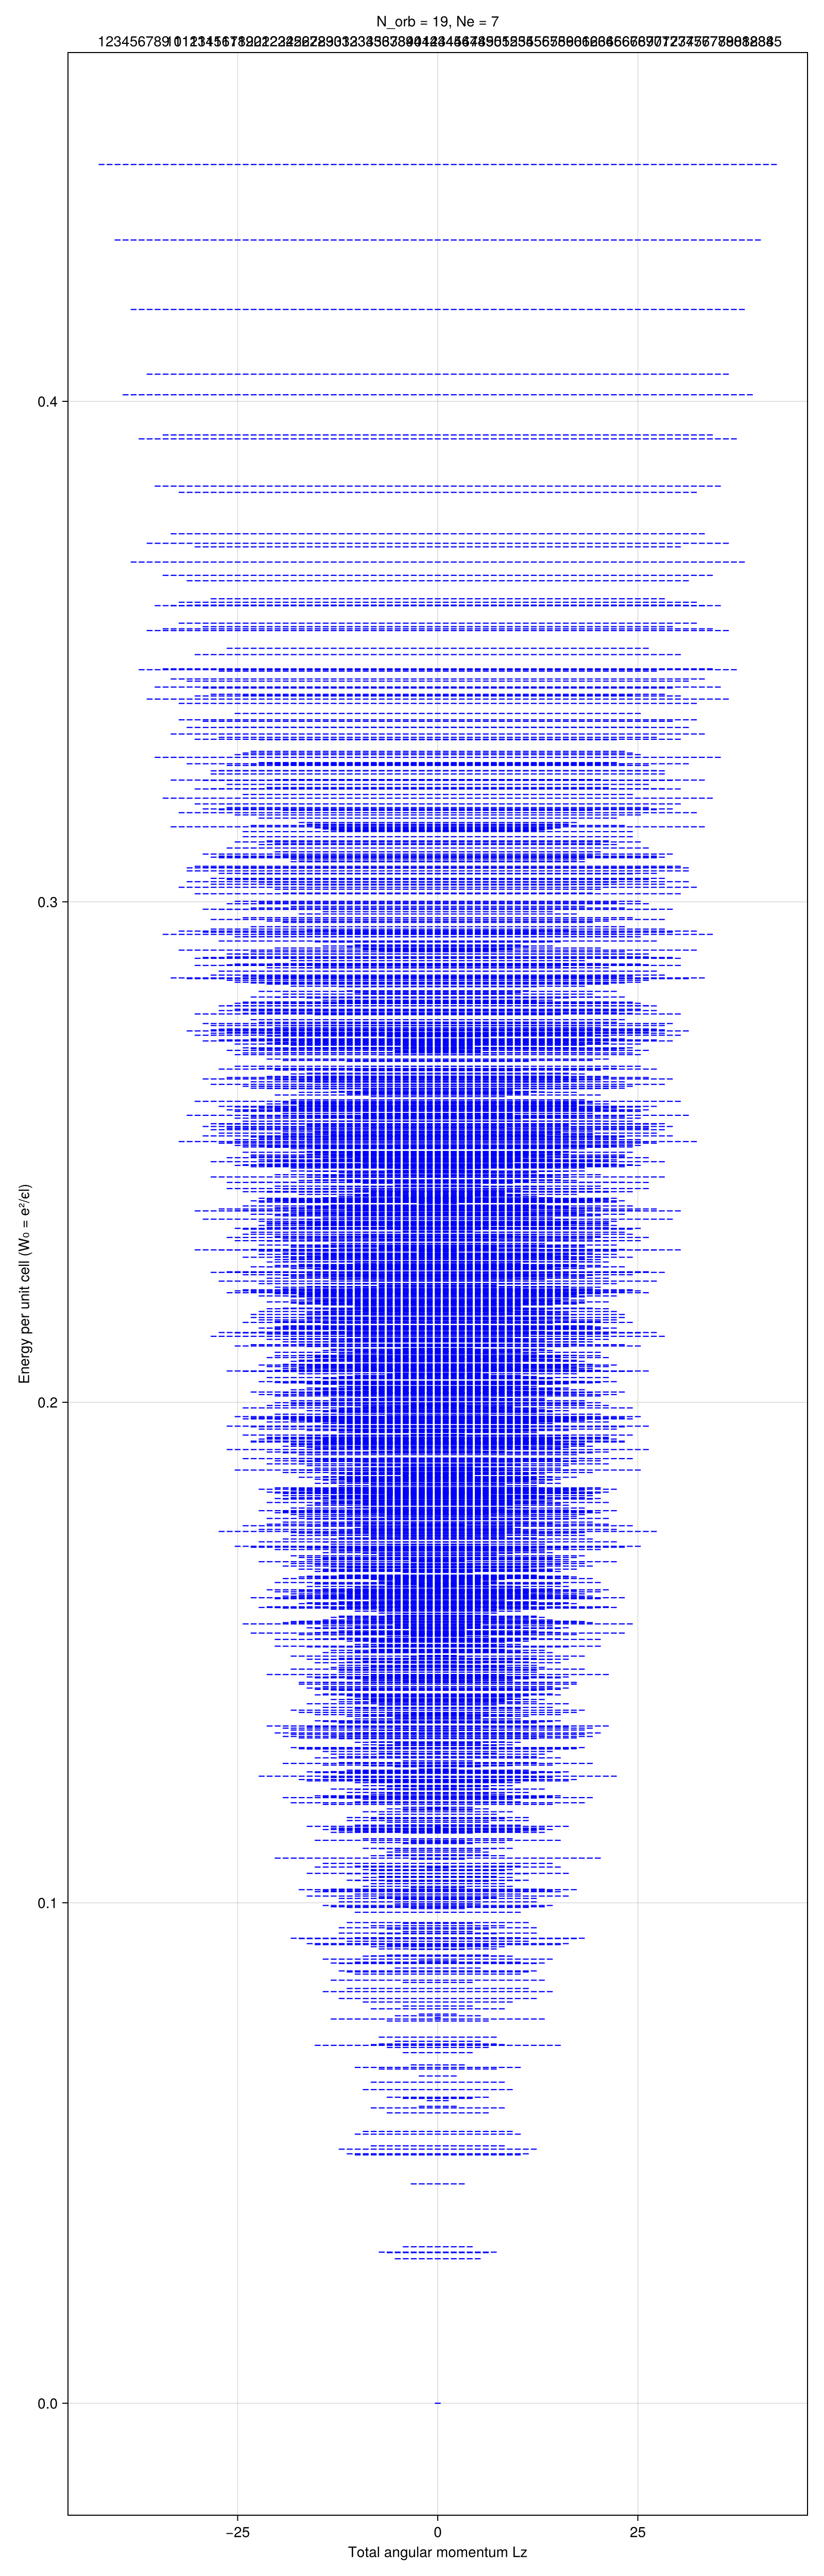

In [29]:
plot_ed_spectrum(energies/N_orb/LLS.W0, ss_k[ss_range];
    title = "N_orb = $N_orb, Ne = $Ne",
    size = (800, 2500)
    # ylims = (0.372, 0.377),
);

In [ ]:
# check energies explicitly to see degeneracy.
sn = ss_center        # the subspace number to inspect (see the top of spectrum plot)
println("total momentum: ", ss_k[ss_range[sn]])
energies[sn]/N_orb/LLS.W0

One-body reduced density matrix

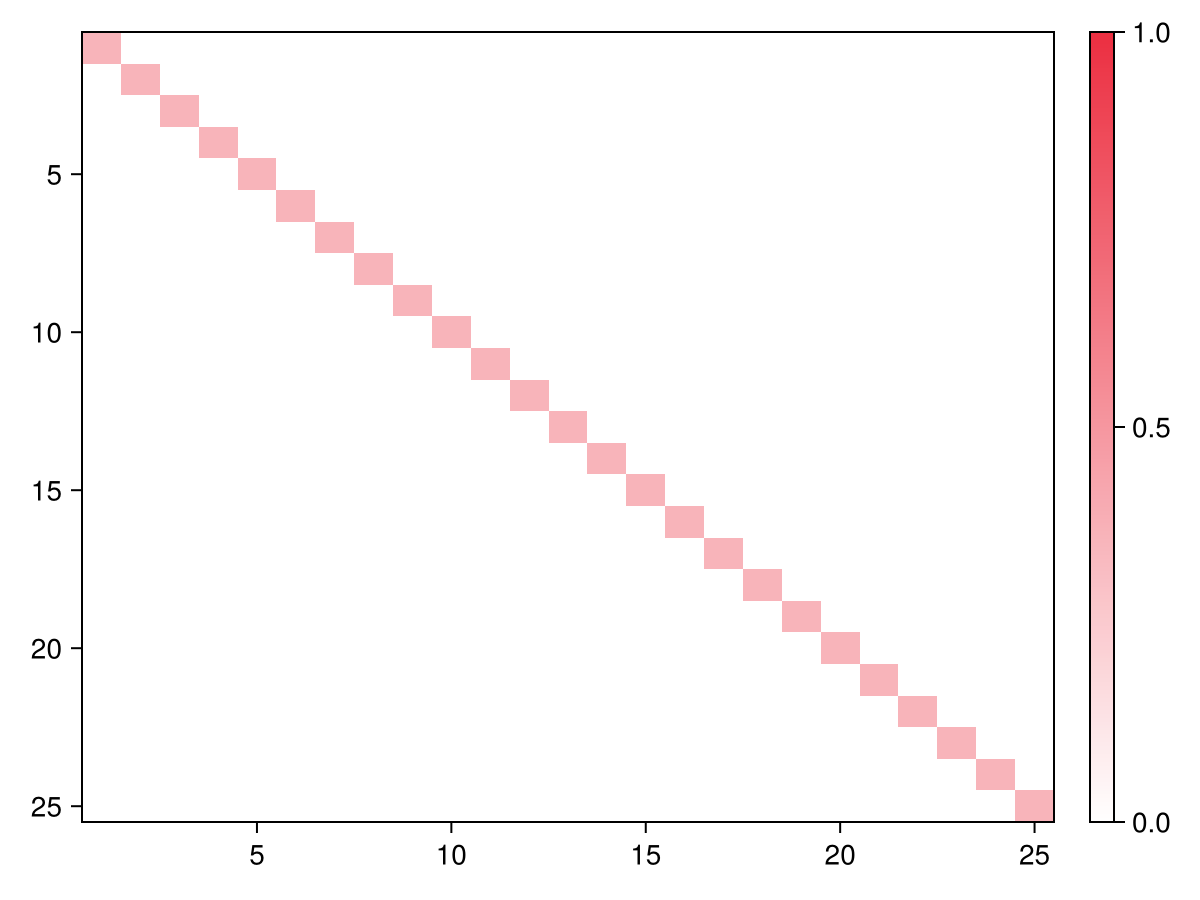

In [ ]:
# plot the one-body reduced density matrix of the ground eigenstate in the first block
sn = ss_center
rdm1 = PES_1rdm(vectors[sn][1])                   # one state

fig, ax, hm = heatmap(abs.(rdm1); colorrange = (0,1), axis = (;yreversed = true),
    colormap = range(Makie.Colors.colorant"white", stop=Makie.Colors.colorant"#ec2f41", length=15)
)
Colorbar(fig[1, 2], hm); fig

# scatterlines(diag(rdm1) .|> abs)

Particle reduced density matrix and entanglement spectrum (PES)

In [117]:
NA = 3  # number of electrons in part A, negtive number means holes in part A
ph_components = BitVector([NA < 0])
normalizer = binomial(ph_components[1] ? N_orb-Ne : Ne, abs(NA))
# Create momentum blocks for part A (Hilbert subspaces)
Ass, Ak = ED_momentum_subspaces(para, (NA, ));

sn_vn_range = [(6,1);];  # use all Laughlin ground states for PES calculation
threshold = 1e-10;                    # eigenvalues smaller than this value will be ignored to avoid numerical instability
entanglement_spectrum = Vector{Vector{Float64}}(undef, length(Ass));
trace = 0.0; entropy = 0.0;
for i in eachindex(entanglement_spectrum)
    println("Processing subspace #$i with size $(length(Ass[i])), momentum $(Ak[i])")
    rdm_l = length(Ass[i])
    rdm = zeros(ComplexF64, rdm_l, rdm_l)
    for (sn, vn) in sn_vn_range
        rdm += PES_MomtBlock_rdm(para, vectors[sn][vn], Ass[i], ph_components)
    end
    rdm /= length(sn_vn_range)

    vals = eigvals(Hermitian(rdm)) ./ normalizer
    trace += sum(vals)
    nonzero_start = findfirst(>(threshold), vals)
    if isnothing(nonzero_start)
        entanglement_spectrum[i] = Vector{Float64}()
        continue
    end
    nonzero_start > 1 && println("the first $(nonzero_start-1) eigenvalues are ignored")
    entanglement_spectrum[i] = -log.(vals[nonzero_start:end])
    entropy += sum(λ -> -λ*log(λ), vals[nonzero_start:end])
end
entropy = (entropy + trace * log(trace)) / trace
@show trace, entropy;

Processing subspace #1 with size 1, momentum (3,)
Processing subspace #2 with size 1, momentum (4,)
Processing subspace #3 with size 2, momentum (5,)
Processing subspace #4 with size 3, momentum (6,)
Processing subspace #5 with size 4, momentum (7,)
Processing subspace #6 with size 5, momentum (8,)
Processing subspace #7 with size 7, momentum (9,)
the first 6 eigenvalues are ignored
Processing subspace #8 with size 8, momentum (10,)
the first 7 eigenvalues are ignored
Processing subspace #9 with size 10, momentum (11,)
the first 8 eigenvalues are ignored
Processing subspace #10 with size 12, momentum (12,)
the first 9 eigenvalues are ignored
Processing subspace #11 with size 14, momentum (13,)
the first 10 eigenvalues are ignored
Processing subspace #12 with size 16, momentum (14,)
the first 11 eigenvalues are ignored
Processing subspace #13 with size 19, momentum (15,)
the first 12 eigenvalues are ignored
Processing subspace #14 with size 21, momentum (16,)
the first 13 eigenvalues ar

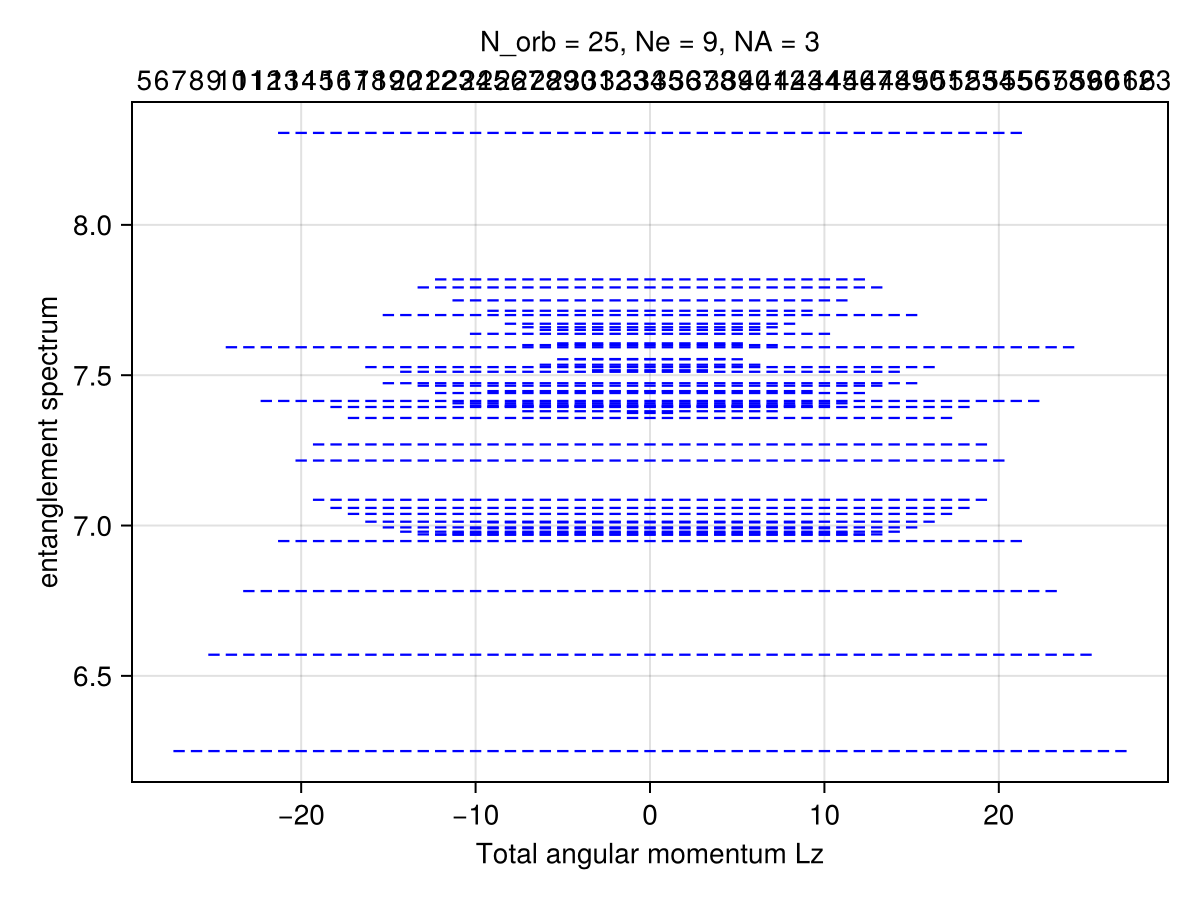

In [120]:
# if using pseudo potential with only V_1 and set V_3=0:
# spectrum above gap are infinity and will be ignored in this plot. 
fig,ax = plot_ed_spectrum(entanglement_spectrum, Ak;
    ylabel = "entanglement spectrum",
    title = "N_orb = $N_orb, Ne = $Ne, NA = $NA",
    # ylims = (nothing, nothing)
)
fig

In [121]:
sum(spec -> count(<=(6.5), spec), entanglement_spectrum)

55

Compute orbital reduced density matrix and entanglement spectrum (OES)

In [123]:
orbitals_A = collect(1:6)
subspacesA_list, subspacesB_list, momentumA_list, momentumB_list = 
    OES_NumMomtBlocks(para, orbitals_A, (Ne, ));
display(momentumA_list);
@show(length.(subspacesA_list));
display(momentumB_list);
@show(length.(subspacesB_list));

MethodError: MethodError: Cannot `convert` an object of type 
  Tuple{Int64} to an object of type 
  Tuple{Int64,Int64}
This error has been manually thrown, explicitly, so the method may exist but be intentionally marked as unimplemented.

Closest candidates are:
  convert(::Type{T}, ::NTuple{N, Any}) where {N, T<:Tuple}
   @ Base essentials.jl:601
  (::Type{T})(::Tuple) where T<:Tuple
   @ Base tuple.jl:449
  (::Type{T})(::Any) where T<:Tuple
   @ Base tuple.jl:454
  ...


In [19]:
# only use one eigenstate to compute OES
vec = vectors[1][1]; momentum = ss_k[1];
entanglement_spectrum = similar(momentumA_list, Vector{Vector{Float64}})
for i in eachindex(entanglement_spectrum)
    coefficient_matrices = OES_NumMomtBlock_coef(para, vec, momentum, 
        subspacesA_list[i], subspacesB_list[i], momentumA_list[i], momentumB_list[i]
    )
    density_matrices = similar(coefficient_matrices, Matrix{ComplexF64})
    for j in eachindex(density_matrices)
        density_matrices[j] = coefficient_matrices[j] * coefficient_matrices[j]'
    end
    entanglement_spectrum[i] = similar(coefficient_matrices, Vector{Float64})
    for j in eachindex(density_matrices)
        vals = real.(eigvals(density_matrices[j]))
        nonzeroposition = findfirst(>(1e-7), vals)
        if isnothing(nonzeroposition)
            entanglement_spectrum[i][j] = [];
        else
            entanglement_spectrum[i][j] = -log.(vals[nonzeroposition:end])
        end
    end
end

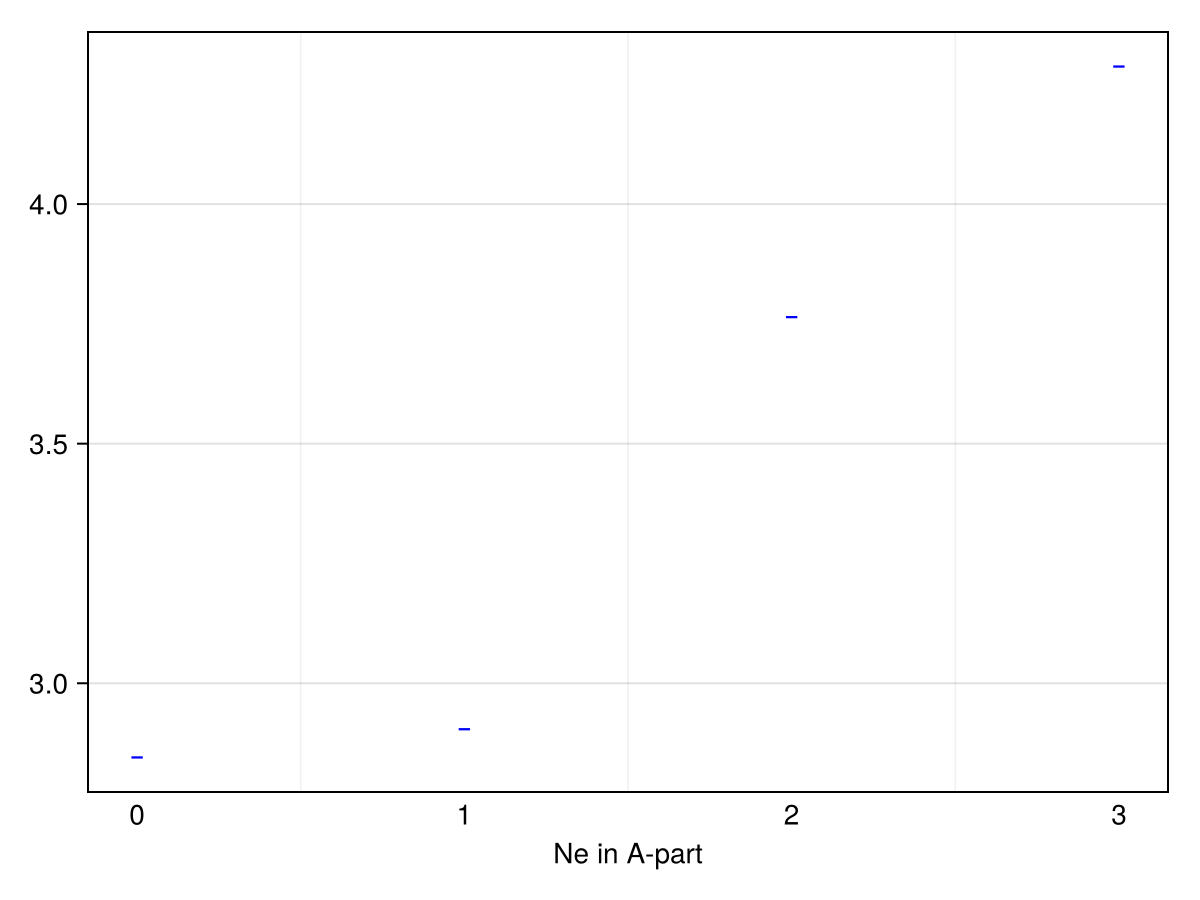

In [20]:
plot_entanglement_spectrum(entanglement_spectrum);

Compute the many-body connection and the Wilson loop for many-body Chern number.

In [21]:
function manybody_overlap(para::EDPara, 
    ψ_f, ψ_i, k_f::Tuple{<:Real, <:Real}, k_i::Tuple{<:Real, <:Real})
    
    orbital_bc = orbital_overlap(para, k_f, k_i)
    return ED_step_inner_prod(ψ_f, ψ_i, orbital_bc)
end

manybody_overlap (generic function with 1 method)

In [22]:
# path for the Wilson loop integral on base manifold
# Landau level has uniform Berry curvature, so we compute Berry curvature of a small plaquate and then multiply plaquate number
N_kshift = 10  # number of shifts along G1 and G2 direction
path = Tuple{Rational, Rational}[(0//1, 0//1)]
push!(path, (1//N_kshift, 0//1))
push!(path, (1//N_kshift, 1//N_kshift))
push!(path, (0//1, 1//N_kshift))
push!(path, (0//1, 0//1))
display(path)

5-element Vector{Tuple{Rational, Rational}}:
 (0, 0)
 (1//10, 0)
 (1//10, 1//10)
 (0, 1//10)
 (0, 0)

In [23]:
# If the 3 ground states are in different momentum section, 
# we can track one of them and compute its many-body Chern number

sn = 1; vn = 1;
psi = similar(path, typeof(vectors[sn][vn]))
for i in eachindex(path)
    if i ∈ (1,5)
        psi[i] = vectors[sn][vn]
        continue
    end
    scat_list = ED_scatterlist_twobody(para; kshift = path[i]);
    psi[i] = EDsolve(subspaces[sn], scat_list; N = 6,
        showtime = false,
    )[2][vn]
end

WilsonLoopIntegral= Vector{ComplexF64}(undef, 4)
for i in eachindex(WilsonLoopIntegral)
    WilsonLoopIntegral[i] = manybody_overlap(para, 
    psi[i+1], psi[i], path[i+1], path[i])
end
ManyBodyChernNumber = angle(prod(WilsonLoopIntegral)) / (2π) * N_kshift^2
#

0.33333333333333454

In [24]:
# If the 3 degenerate ground states are in the same total momentum section, 
# we can only compute the sum of the tatal connection and Chern number.

#=
sn = 10; vn_range = 1:3;
psi = similar(path, Vector{typeof(vectors[sn][1])})
for i in eachindex(path)
    if i ∈ (1,5)
        psi[i] = vectors[sn][vn_range]
        continue
    end
    scat_list = ED_scatterlist_twobody(para; kshift = path[i]);
    psi[i] = EDsolve(subspaces[sn], scat_list; N = 6,
        showtime = false,
    )[2][vn_range]
end

WilsonLoopIntegral = Vector{Matrix{ComplexF64}}(undef, 4)
for i in eachindex(WilsonLoopIntegral)
    WilsonLoopIntegral[i] = manybody_overlap(para, 
    psi[i+1], psi[i], path[i+1], path[i])
end
ManyBodyChernNumber = angle(det(prod(WilsonLoopIntegral))) / (2π) * N_kshift^2
ManyBodyChernNumber /= length(vn_range)
=#